In [4]:
import torch 
import torch.nn as nn
import torchvision

from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision import transforms
import torch.nn as nn
from torch.utils.tensorboard import SummaryWriter

from pathlib import Path

import matplotlib.pyplot as plt

from torchinfo import summary

from PIL import Image
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
Image.open("all-of-the-pizzas-consumed-on-our-east-coast-trip-v0-2t9mwthxa3ua1.webp").save("custom_pizza.png")


In [20]:
def create_effnetb2():

    weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT
    model = torchvision.models.efficientnet_b2(weights = weights).to(device)

    for param in model.features.parameters():
        param.requires_grad = False
    model.classifier = nn.Sequential(
        nn.Dropout(p=.02, inplace=True),
        nn.Linear(in_features=1408, out_features=3, bias=True)
    )

    return model
model = create_effnetb2().to(device)

In [21]:
model.load_state_dict(torch.load("models/07_effnetb2_data_20_percent_10_epochs.pth"))

<All keys matched successfully>

In [ ]:

weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT
transforms = weights.transforms()
image = transforms(Image.open("custom_pizza.png")).unsqueeze(dim=0).to(device)
pred = model(image)

In [ ]:
prob = torch.softmax(pred, dim=1)
print(prob)
prob.max(dim=1).values.item()

tensor([[0.3971, 0.2895, 0.3134]], device='cuda:0', grad_fn=<SoftmaxBackward0>)


0.3971024453639984

In [41]:
test_data = datasets.ImageFolder("pizz_steak_sushi_10/test", transform = transforms)
test_dataloader = DataLoader(test_data, batch_size=32)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6051416].


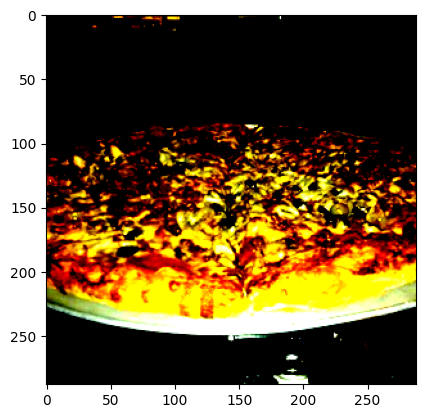

In [45]:
image, label = next(iter(test_dataloader))
plt.imshow(image[0].permute(1,2,0))

In [47]:
len(test_dataloader)

3

In [48]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

In [61]:
test_acc = 0

with torch.inference_mode():
    model.eval()
    for X, y in test_dataloader:
        X = X.to(device)
        y = y.to(device)
        pred = model(X)
        test_acc += (pred.argmax(dim=1) == y).float().mean().item()

    test_acc /= len(test_dataloader)



In [62]:
test_acc

0.8863636453946432